# Affine Models of Asset Prices

This notebook implements the **affine (exponential-quadratic) term structure model** 
from chapter 15 of Ljungqvist & Sargent, *Recursive Macroeconomic Theory* (5th ed.).

Key objects:
- **State dynamics**: $z_{t+1} = \mu + \phi z_t + C\varepsilon_{t+1}$
- **Short rate**: $r_t = \delta_0 + \delta_1' z_t$
- **Risk prices**: $\lambda_t = \lambda_0 + \lambda_z z_t$
- **Log SDF**: $\log m_{t+1} = -r_t - \tfrac{1}{2}\lambda_t'\lambda_t - \lambda_t'\varepsilon_{t+1}$

We explore how risk prices shape yield curves, how persistence drives term premiums,
and how distorted beliefs inflate econometric risk-price estimates.

## 1. Import Required Libraries

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import matrix_power, eigvals

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
})

## 2. Define the AffineTermStructure Class

The class encapsulates the model:

$$z_{t+1} = \mu + \phi z_t + C\varepsilon_{t+1}, \quad r_t = \delta_0 + \delta_1' z_t, \quad \lambda_t = \lambda_0 + \lambda_z z_t$$

Bond prices satisfy $p_t(n) = \exp(\bar{A}_n + \bar{B}_n' z_t)$ where $(\bar{A}_n, \bar{B}_n)$ obey a Riccati recursion.

In [10]:
class AffineTermStructure:
    """
    Affine term structure model (Ang & Piazzesi 2003, RMT5 ch. 15).

    State dynamics:
        z_{t+1} = μ + φ z_t + C ε_{t+1},   ε ~ N(0, I)
    Short rate:
        r_t = δ_0 + δ_1' z_t
    Risk prices:
        λ_t = λ_0 + λ_z z_t
    Log SDF:
        log(m_{t+1}) = -r_t - ½ λ_t'λ_t - λ_t'ε_{t+1}
    """

    def __init__(self, mu, phi, C, delta0, delta1, lambda0, lambdaz):
        self.mu = np.asarray(mu, dtype=float)
        self.phi = np.asarray(phi, dtype=float)
        self.C = np.asarray(C, dtype=float)
        self.delta0 = float(delta0)
        self.delta1 = np.asarray(delta1, dtype=float)
        self.lambda0 = np.asarray(lambda0, dtype=float)
        self.lambdaz = np.asarray(lambdaz, dtype=float)
        self.m = len(self.mu)
        # Risk-neutral drift: φ^Q = φ - Cλ_z,  μ^Q = μ - Cλ_0
        self.phi_rn = self.phi - self.C @ self.lambdaz
        self.mu_rn = self.mu - self.C @ self.lambda0

    def bond_coefficients(self, n_max):
        """
        Riccati recursion for (Ā_n, B̄_n), n = 1, …, n_max.

        Ā_1 = -δ_0,   B̄_1 = -δ_1
        Ā_{n+1} = Ā_n + B̄_n'(μ - Cλ_0) + ½ B̄_n'CC'B̄_n - δ_0
        B̄_{n+1} = (φ - Cλ_z)' B̄_n - δ_1
        """
        A_bar = np.zeros(n_max + 1)
        B_bar = np.zeros((n_max + 1, self.m))
        A_bar[1] = -self.delta0
        B_bar[1] = -self.delta1
        CC = self.C @ self.C.T

        for n in range(1, n_max):
            Bn = B_bar[n]
            A_bar[n + 1] = (A_bar[n]
                            + Bn @ self.mu_rn
                            + 0.5 * Bn @ CC @ Bn
                            - self.delta0)
            B_bar[n + 1] = self.phi_rn.T @ Bn - self.delta1
        return A_bar, B_bar

    def yields(self, z, n_max):
        """Yield curve y_t(n) = -Ā_n/n - B̄_n'z/n for n=1,…,n_max."""
        A_bar, B_bar = self.bond_coefficients(n_max)
        ns = np.arange(1, n_max + 1)
        y = np.array([(-A_bar[n] - B_bar[n] @ z) / n for n in ns])
        return y

    def bond_prices(self, z, n_max):
        """Bond prices p_t(n) = exp(Ā_n + B̄_n'z)."""
        A_bar, B_bar = self.bond_coefficients(n_max)
        p = np.array([np.exp(A_bar[n] + B_bar[n] @ z)
                      for n in range(1, n_max + 1)])
        return p

    def simulate(self, z0, T, rng=None):
        """Simulate state process for T periods under the physical measure P."""
        if rng is None:
            rng = np.random.default_rng(42)
        Z = np.zeros((T + 1, self.m))
        Z[0] = z0
        for t in range(T):
            eps = rng.standard_normal(self.m)
            Z[t + 1] = self.mu + self.phi @ Z[t] + self.C @ eps
        return Z

    def short_rate(self, z):
        """r_t = δ_0 + δ_1'z_t."""
        return self.delta0 + self.delta1 @ z

    def risk_prices(self, z):
        """λ_t = λ_0 + λ_z z_t."""
        return self.lambda0 + self.lambdaz @ z

    def expected_excess_return(self, z, alpha0, alphaz):
        """ν_t(j) - r_t = α_t(j)'λ_t."""
        alpha_t = alpha0 + alphaz @ z
        lambda_t = self.risk_prices(z)
        return alpha_t @ lambda_t


def term_premiums(model, z, n_max):
    """
    Term premium for holding an (n+1)-period bond one period:
        tp(n) = -B̄_n' C λ_t
    """
    A_bar, B_bar = model.bond_coefficients(n_max + 1)
    lambda_t = model.risk_prices(z)
    tp = np.array([-B_bar[n] @ model.C @ lambda_t
                   for n in range(1, n_max + 1)])
    return tp

## 3. One-Factor Gaussian Model

We start with a single-factor ($m=1$) model. The state $z_t$ follows an AR(1):

$$z_{t+1} = \mu(1-\phi) + \phi z_t + \sigma\varepsilon_{t+1}$$

**Parameter interpretation (quarterly frequency):**
- $\phi = 0.95$: moderately persistent short rate (half-life ≈ 14 quarters)
- $\lambda_0 = 0.5$: positive average risk price → positive average term premium
- $\lambda_z = -20$: risk prices *fall* when the state rises → term premiums are countercyclical

### Key stability requirement

The **risk-neutral** autoregressive matrix $\phi^Q = \phi - C\lambda_z$ must have all eigenvalues **inside the unit circle**. Otherwise the Riccati coefficients $\bar{B}_n$ grow without bound and yields explode.

We use a **standardized-state** parametrization: $C = I$ (identity) so that the shocks $\varepsilon_{t+1}$ enter the state directly. The short rate loading $\delta_1$ is then a small vector (measured in per-quarter yield units per standard deviation of the state). This keeps risk-neutral dynamics well-behaved while allowing economically meaningful risk prices.

In [11]:
# ── One-factor Gaussian model (quarterly, standardized state) ───────────
# z_t has unit innovation variance; C = I absorbs the volatility.
# δ_1 translates z into short-rate units (small: ~1bp per unit of z).

mu      = np.array([0.0])          # VAR intercept → E[z]=0
phi     = np.array([[0.95]])       # persistence
C       = np.array([[1.0]])        # identity (standardized shocks)
delta0  = 0.01                     # base short rate: 1%/quarter = 4% p.a.
delta1  = np.array([0.001])        # ≈ 40bp p.a. per std-dev of z
lambda0 = np.array([0.05])         # constant risk price
lambdaz = np.array([[-0.01]])      # countercyclical (λ falls when z rises)

model_1f = AffineTermStructure(mu, phi, C, delta0, delta1, lambda0, lambdaz)

# Check stability
phi_Q = model_1f.phi_rn[0, 0]
half_life = np.log(2) / (-np.log(phi[0, 0]))
uncond_std_z = 1.0 / np.sqrt(1 - phi[0,0]**2)   # std dev of stationary z
print(f"Physical AR(1):      φ   = {phi[0,0]:.3f}  (half-life {half_life:.1f} quarters)")
print(f"Risk-neutral AR(1):  φ^Q = {phi_Q:.3f}  "
      f"{'✓ stable' if abs(phi_Q) < 1 else '✗ UNSTABLE!'}")
print(f"Unconditional std of z:  σ_z = {uncond_std_z:.2f}")
print(f"Mean short rate = {model_1f.short_rate(np.array([0.0]))*4*100:.1f}% p.a.")
print(f"Short rate range (±2σ): [{(delta0-delta1[0]*2*uncond_std_z)*4*100:.1f}%, "
      f"{(delta0+delta1[0]*2*uncond_std_z)*4*100:.1f}%] p.a.")

Physical AR(1):      φ   = 0.950  (half-life 13.5 quarters)
Risk-neutral AR(1):  φ^Q = 0.960  ✓ stable
Unconditional std of z:  σ_z = 3.20
Mean short rate = 4.0% p.a.
Short rate range (±2σ): [1.4%, 6.6%] p.a.


## 4. Yield Curve Shapes — One-Factor Model

We plot yield curves at three levels of $z_t$: low, median, and high.
- **Low state** ($z = -0.02$): short rate is low → upward-sloping curve
- **Median state** ($z = 0.01$): near the unconditional mean
- **High state** ($z = 0.04$): short rate is high → inverted curve

Maturities run from 1 to 60 quarters (15 years) — a realistic range for
viewing the economic forces at work. The original 120-period plot compressed
the interesting short-to-medium maturity structure.

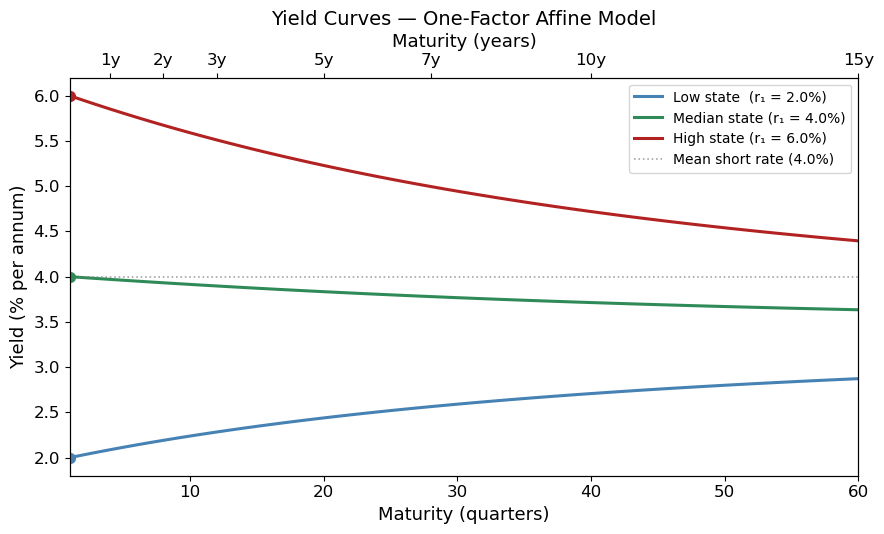

In [12]:
# ── Yield curves: one-factor model ──────────────────────────────────────
n_max_1f = 60   # 60 quarters = 15 years
maturities_1f = np.arange(1, n_max_1f + 1)

# Three states spanning the short-rate range
# z < 0 → low short rate, z > 0 → high short rate
z_low  = np.array([-5.0])     # short rate well below mean → expect rise → upward slope
z_mid  = np.array([0.0])      # at the mean
z_high = np.array([5.0])      # short rate well above mean → expect decline → inverted

fig, ax = plt.subplots(figsize=(9, 5.5))

for z, label, color in [
    (z_low,  f"Low state  (r₁ = {model_1f.short_rate(z_low)*4*100:.1f}%)", "steelblue"),
    (z_mid,  f"Median state (r₁ = {model_1f.short_rate(z_mid)*4*100:.1f}%)", "seagreen"),
    (z_high, f"High state (r₁ = {model_1f.short_rate(z_high)*4*100:.1f}%)", "firebrick"),
]:
    y = model_1f.yields(z, n_max_1f) * 4 * 100   # annualised %
    ax.plot(maturities_1f, y, color=color, lw=2.2, label=label)
    ax.plot(1, y[0], 'o', color=color, ms=7, zorder=5)

# Mark unconditional mean short rate
r_bar = model_1f.short_rate(np.array([0.0])) * 4 * 100
ax.axhline(r_bar, color='grey', ls=':', lw=1.2, alpha=0.7,
           label=f"Mean short rate ({r_bar:.1f}%)")

ax.set_xlabel("Maturity (quarters)")
ax.set_ylabel("Yield (% per annum)")
ax.set_title("Yield Curves — One-Factor Affine Model")
ax.legend(fontsize=10, loc='best')
ax.set_xlim(1, n_max_1f)

# Secondary x-axis in years
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
year_ticks = [4, 8, 12, 20, 28, 40, 60]
ax2.set_xticks(year_ticks)
ax2.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])
ax2.set_xlabel("Maturity (years)")

plt.tight_layout()
plt.show()

## 5. Simulated Short Rate Dynamics

The short rate $r_t = \delta_0 + \delta_1 z_t$ inherits the AR(1) mean-reversion of $z_t$.
We simulate 200 quarters (50 years) to show the cyclical behaviour.

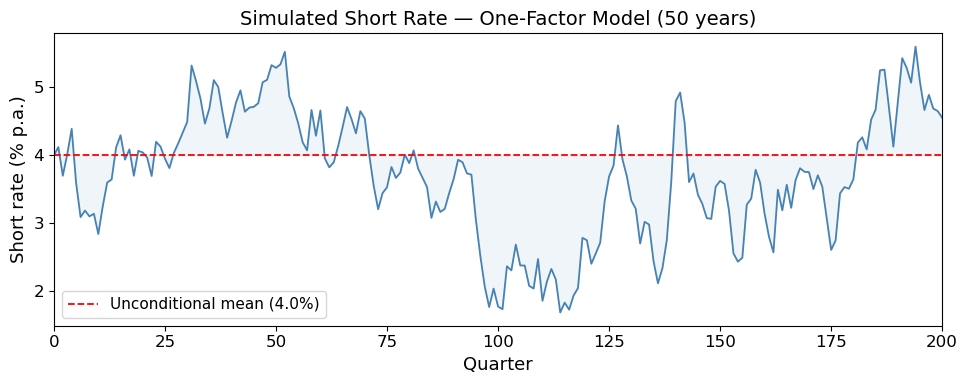

In [13]:
# ── Simulated short rate ────────────────────────────────────────────────
T = 200
Z = model_1f.simulate(np.array([0.0]), T)
short_rates = np.array([model_1f.short_rate(Z[t]) * 4 * 100 for t in range(T + 1)])
r_bar_pct = model_1f.short_rate(np.array([0.0])) * 4 * 100

fig, ax = plt.subplots(figsize=(10, 4))
quarters = np.arange(T + 1)
ax.plot(quarters, short_rates, color="steelblue", lw=1.3)
ax.axhline(r_bar_pct, color="red", ls="--", lw=1.3,
           label=f"Unconditional mean ({r_bar_pct:.1f}%)")
ax.fill_between(quarters, short_rates, r_bar_pct, alpha=0.08, color="steelblue")
ax.set_xlabel("Quarter")
ax.set_ylabel("Short rate (% p.a.)")
ax.set_title("Simulated Short Rate — One-Factor Model (50 years)")
ax.set_xlim(0, T)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 6. Two-Factor Model Setup

A two-factor model adds a **slope** component to the **level**:
- Factor 1 (level): very persistent ($\phi_{11} = 0.97$), drives long-run yield level
- Factor 2 (slope): moderately persistent ($\phi_{22} = 0.90$), steepens/flattens the curve
- Cross-loading $\phi_{12} = -0.03$: slope innovations feed back into future level

With $C = I$, the risk-neutral VAR parameters are $\phi^Q = \phi - \lambda_z$ and $\mu^Q = \mu - \lambda_0$.

In [18]:
# ── Two-factor model (quarterly, standardized state) ────────────────────
mu2      = np.array([0.0,  0.0])
phi2     = np.array([[0.97, -0.03],    # level very persistent, slope feeds back
                     [0.00,  0.90]])   # slope moderately persistent
C2       = np.array([[1.0, 0.0],       # identity (standardized shocks)
                     [0.0, 1.0]])
delta0_2 = 0.01                         # base short rate = 4% p.a.
delta1_2 = np.array([0.002, 0.001])     # level matters more for r
lambda0_2 = np.array([0.01,  0.005])    # small constant risk prices
lambdaz_2 = np.array([[-0.005, 0.0],    # level risk price falls when level rises
                      [ 0.0, -0.003]])  # slope risk price falls when slope rises

model_2f = AffineTermStructure(mu2, phi2, C2,
                                delta0_2, delta1_2,
                                lambda0_2, lambdaz_2)

print("Physical measure VAR:")
print(f"  φ =\n{phi2}")
print(f"  eigenvalues of φ: {eigvals(phi2).real.round(4)}")
print()
print("Risk-neutral measure VAR:")
print(f"  φ^Q = φ - Cλ_z =\n{model_2f.phi_rn.round(4)}")
eigs_Q = eigvals(model_2f.phi_rn).real
print(f"  eigenvalues of φ^Q: {eigs_Q.round(4)}")
stable = all(abs(e) < 1 for e in eigs_Q)
print(f"  {'✓ All eigenvalues inside unit circle' if stable else '✗ UNSTABLE!'}")
print()
print("→ Risk prices make Q dynamics MORE persistent than P dynamics")

Physical measure VAR:
  φ =
[[ 0.97 -0.03]
 [ 0.    0.9 ]]
  eigenvalues of φ: [0.97 0.9 ]

Risk-neutral measure VAR:
  φ^Q = φ - Cλ_z =
[[ 0.975 -0.03 ]
 [ 0.     0.903]]
  eigenvalues of φ^Q: [0.975 0.903]
  ✓ All eigenvalues inside unit circle

→ Risk prices make Q dynamics MORE persistent than P dynamics


## 7. Yield Curves and Factor Loadings — Two-Factor Model

**Left panel**: Yield curves for three (level, slope) combinations.
**Right panel**: The yield-loading vectors $B_n = -\bar{B}_n / n$ show how each factor
contributes to the $n$-period yield. At long maturities, the level factor dominates;
the slope factor matters most at short-to-medium maturities.

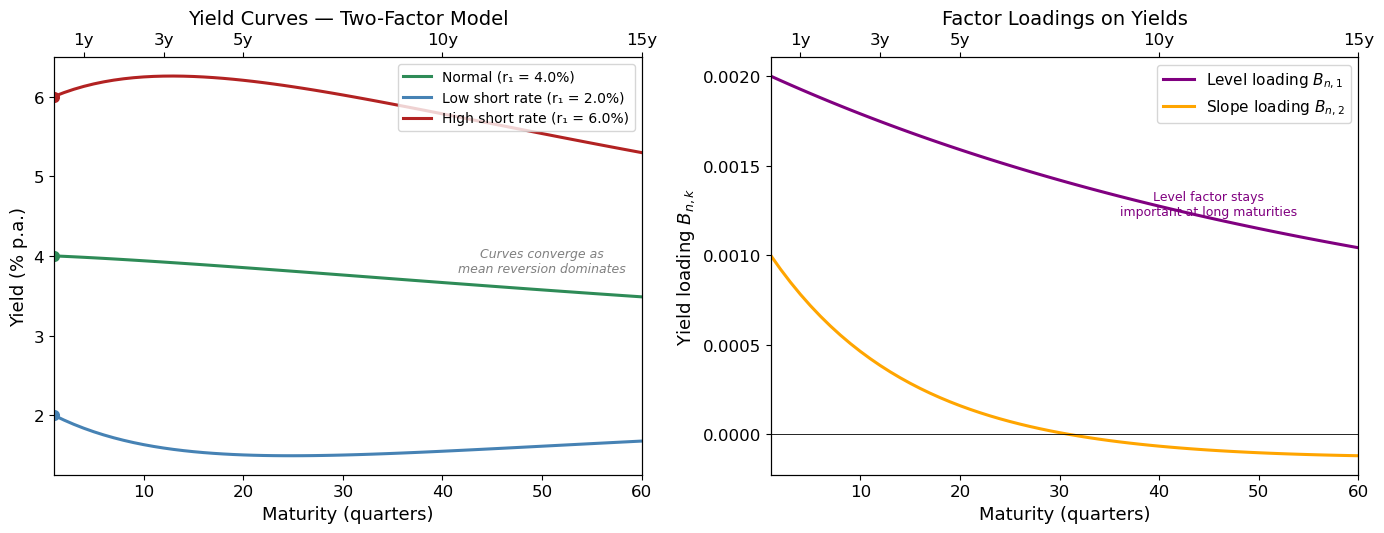

In [20]:
# ── Yield curves + factor loadings: two-factor model ────────────────────
n_max_2f = 60
maturities_2f = np.arange(1, n_max_2f + 1)

states = {
    "Normal":              np.array([0.0,   0.0]),
    "Low short rate":      np.array([-4.0,  3.0]),
    "High short rate":     np.array([4.0,  -3.0]),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: Yield curves ──
colors_2f = ["seagreen", "steelblue", "firebrick"]
for (label, z), color in zip(states.items(), colors_2f):
    r_now = model_2f.short_rate(z) * 4 * 100
    y = model_2f.yields(z, n_max_2f) * 4 * 100
    ax1.plot(maturities_2f, y, lw=2.2, color=color,
             label=f"{label} (r₁ = {r_now:.1f}%)")
    ax1.plot(1, y[0], 'o', color=color, ms=7, zorder=5)

ax1.annotate("Curves converge as\nmean reversion dominates",
             xy=(50, 3.8), fontsize=9, color="gray", ha='center',
             style='italic')
ax1.set_xlabel("Maturity (quarters)")
ax1.set_ylabel("Yield (% p.a.)")
ax1.set_title("Yield Curves — Two-Factor Model")
ax1.legend(fontsize=10)
ax1.set_xlim(1, n_max_2f)

# ── Right: Factor loadings B_n ──
A_bar, B_bar = model_2f.bond_coefficients(n_max_2f)
ns = np.arange(1, n_max_2f + 1)
B_n = np.array([-B_bar[n] / n for n in ns])   # B_n = -B̄_n / n

ax2.plot(ns, B_n[:, 0], lw=2.2, color="purple", label=r"Level loading $B_{n,1}$")
ax2.plot(ns, B_n[:, 1], lw=2.2, color="orange", label=r"Slope loading $B_{n,2}$")
ax2.axhline(0, color='black', lw=0.6)
ax2.set_xlabel("Maturity (quarters)")
ax2.set_ylabel(r"Yield loading $B_{n,k}$")
ax2.set_title("Factor Loadings on Yields")
ax2.legend(fontsize=11)
ax2.set_xlim(1, n_max_2f)
ax2.annotate("Level factor stays\nimportant at long maturities",
             xy=(45, B_n[44, 0]), fontsize=9, color="purple",
             ha='center', va='bottom')

# Year labels on top
for ax in (ax1, ax2):
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    year_ticks = [4, 12, 20, 40, 60]
    ax_top.set_xticks(year_ticks)
    ax_top.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])

plt.tight_layout()
plt.show()

## 8. Term Premium Decomposition

The term premium for holding an $(n+1)$-period bond one period is:

$$\text{tp}(n) = -\bar{B}_n' C \lambda_t$$

**Left panel**: Total term premium at two states (low vs. high short rate).
**Right panel**: Decomposition into each factor's contribution:
$\text{tp}_k(n) = -\bar{B}_{n,k}\,(C\lambda_t)_k$ for $k = 1$ (level) and $k=2$ (slope).

When $\lambda_z \neq 0$, the term premium is **state-dependent** — it varies across regimes.

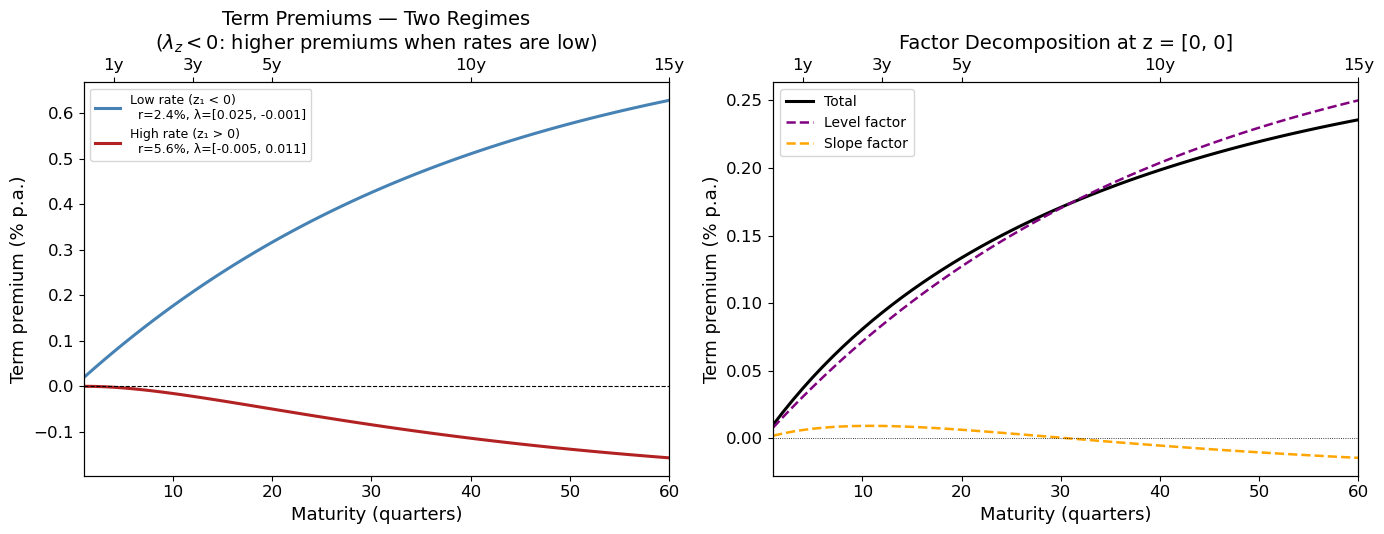

In [21]:
# ── Term premiums with decomposition ────────────────────────────────────
n_max_tp = 60
maturities_tp = np.arange(1, n_max_tp + 1)

z_states_tp = {
    "Low rate (z₁ < 0)":  np.array([-3.0, 2.0]),
    "High rate (z₁ > 0)": np.array([3.0, -2.0]),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: Total term premiums at two states ──
tp_colors = ["steelblue", "firebrick"]
for (label, z), color in zip(z_states_tp.items(), tp_colors):
    tp = term_premiums(model_2f, z, n_max_tp) * 4 * 100   # annualised %
    r_now = model_2f.short_rate(z) * 4 * 100
    lam = model_2f.risk_prices(z)
    ax1.plot(maturities_tp, tp, color=color, lw=2.2,
             label=f"{label}\n  r={r_now:.1f}%, λ=[{lam[0]:.3f}, {lam[1]:.3f}]")

ax1.axhline(0, color="black", lw=0.8, ls="--")
ax1.set_xlabel("Maturity (quarters)")
ax1.set_ylabel("Term premium (% p.a.)")
ax1.set_title("Term Premiums — Two Regimes\n"
              r"($\lambda_z < 0$: higher premiums when rates are low)")
ax1.legend(fontsize=9)
ax1.set_xlim(1, n_max_tp)

# ── Right: Decomposition by factor at z = [0,0] ──
z_decomp = np.array([0.0, 0.0])
A_bar_d, B_bar_d = model_2f.bond_coefficients(n_max_tp + 1)
lam_t = model_2f.risk_prices(z_decomp)
C_lam = model_2f.C @ lam_t

tp_level = np.array([-B_bar_d[n, 0] * C_lam[0]
                      for n in range(1, n_max_tp + 1)]) * 4 * 100
tp_slope = np.array([-B_bar_d[n, 1] * C_lam[1]
                      for n in range(1, n_max_tp + 1)]) * 4 * 100
tp_total = tp_level + tp_slope

ax2.plot(maturities_tp, tp_total, 'k-', lw=2.2, label="Total")
ax2.plot(maturities_tp, tp_level, color="purple", lw=1.8, ls="--",
         label="Level factor")
ax2.plot(maturities_tp, tp_slope, color="orange", lw=1.8, ls="--",
         label="Slope factor")
ax2.axhline(0, color="black", lw=0.6, ls=":")
ax2.set_xlabel("Maturity (quarters)")
ax2.set_ylabel("Term premium (% p.a.)")
ax2.set_title("Factor Decomposition at z = [0, 0]")
ax2.legend(fontsize=10)
ax2.set_xlim(1, n_max_tp)

# Year labels
for ax in (ax1, ax2):
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    year_ticks = [4, 12, 20, 40, 60]
    ax_top.set_xticks(year_ticks)
    ax_top.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])

plt.tight_layout()
plt.show()

## 9. Risk-Neutral Monte Carlo Verification

We verify the Riccati recursion by pricing bonds under the risk-neutral measure $Q$:

$$p_t(n) = \mathbb{E}^Q_t\!\left[\exp\!\left(-\sum_{s=0}^{n-1} r_{t+s}\right)\right]$$

The risk-neutral VAR is $z_{t+1} = \mu^Q + \phi^Q z_t + C\varepsilon^Q_{t+1}$ where $\varepsilon^Q \sim N(0,I)$ under $Q$.

In [22]:
# ── Risk-neutral Monte Carlo verification ──────────────────────────────
def bond_price_monte_carlo_Q(model, z0, n, n_sims=50_000, rng=None):
    """Estimate p_t(n) by Monte Carlo under Q."""
    if rng is None:
        rng = np.random.default_rng(2024)
    m_dim = len(z0)
    Z = np.tile(z0, (n_sims, 1))
    disc = np.zeros(n_sims)
    phi_Q = model.phi_rn
    mu_Q  = model.mu_rn
    C_mat = model.C
    for _ in range(n):
        r_t = model.delta0 + Z @ model.delta1
        disc += r_t
        eps = rng.standard_normal((n_sims, m_dim))
        Z = mu_Q + Z @ phi_Q.T + eps @ C_mat.T
    return np.mean(np.exp(-disc))

# Compare at selected maturities
z_test = np.array([0.01, 0.005])
n_max_test = 40
p_analytic = model_2f.bond_prices(z_test, n_max_test)

rng = np.random.default_rng(2024)
maturities_check = [4, 12, 24, 40]
mc_prices = [bond_price_monte_carlo_Q(model_2f, z_test, n, n_sims=80_000, rng=rng)
             for n in maturities_check]

print(f"{'Maturity':>10}  {'Analytic':>12}  {'Monte Carlo':>12}  {'Error (bps)':>12}")
print("-" * 52)
for n, mc in zip(maturities_check, mc_prices):
    analytic = p_analytic[n - 1]
    error_bp = abs(analytic - mc) / analytic * 10_000
    print(f"{n:>10}  {analytic:>12.6f}  {mc:>12.6f}  {error_bp:>12.2f}")

  Maturity      Analytic   Monte Carlo   Error (bps)
----------------------------------------------------
         4      0.960871      0.960861          0.10
        12      0.888777      0.888591          2.09
        24      0.795043      0.794449          7.47
        40      0.692775      0.693730         13.78


## 10. Distorted Beliefs: Parameter Recovery

Piazzesi, Salomao & Schneider (2015) find that experts' subjective beliefs imply 
a **more persistent** VAR than the physical measure. This section recovers the 
distortion parameters $\kappa_0, \kappa_z$ from the gap between $(\mu_P, \phi_P)$
and $(\hat\mu, \hat\phi)$:

$$\hat\mu = \mu - C\kappa_0, \quad \hat\phi = \phi - C\kappa_z$$

In [23]:
# ── Distorted beliefs: recover κ_0, κ_z ────────────────────────────────
phi_P = phi2.copy()
mu_P  = mu2.copy()

# Subjective parameters: experts believe factors are MORE persistent
phi_S = np.array([[0.985, -0.025], [0.00, 0.94]])
mu_S  = np.array([-0.005, 0.0])

# With C = I, distortion parameters are simply:
# κ_z = C⁻¹(φ_P - φ_S) = φ_P - φ_S
# κ_0 = C⁻¹(μ_P - μ_S) = μ_P - μ_S
C2_mat = model_2f.C
kappa_z = np.linalg.solve(C2_mat, phi_P - phi_S)
kappa_0 = np.linalg.solve(C2_mat, mu_P - mu_S)

print("Distortion parameters (κ quantifies how experts' beliefs differ from P):")
print(f"  κ_0 = {kappa_0.round(4)}")
print(f"  κ_z =\n{kappa_z.round(4)}")
print()
print("Eigenvalue comparison:")
eig_P = sorted(eigvals(phi_P).real, reverse=True)
eig_S = sorted(eigvals(phi_S).real, reverse=True)
print(f"  Physical φ eigenvalues:   {[round(e, 4) for e in eig_P]}")
print(f"  Subjective φ̂ eigenvalues: {[round(e, 4) for e in eig_S]}")
print("  → Experts believe both factors are more persistent")
print()

# True risk prices (what a correctly-specified agent would use)
lambda_star_0 = np.array([0.03, 0.015])
lambda_star_z = np.array([[-0.006, 0.0], [0.0, -0.004]])

# Econometrician who ignores belief distortion attributes:
lambda_hat_0 = lambda_star_0 + kappa_0
lambda_hat_z = lambda_star_z + kappa_z

print("True risk prices:         λ*_0 =", lambda_star_0.round(4))
print("Econometrician estimates: λ̂_0  =", lambda_hat_0.round(4))
print(f"  → Belief distortion inflates λ̂_0 by κ_0 = {kappa_0.round(4)}")

Distortion parameters (κ quantifies how experts' beliefs differ from P):
  κ_0 = [0.005 0.   ]
  κ_z =
[[-0.015 -0.005]
 [ 0.    -0.04 ]]

Eigenvalue comparison:
  Physical φ eigenvalues:   [0.97, 0.9]
  Subjective φ̂ eigenvalues: [0.985, 0.94]
  → Experts believe both factors are more persistent

True risk prices:         λ*_0 = [0.03  0.015]
Econometrician estimates: λ̂_0  = [0.035 0.015]
  → Belief distortion inflates λ̂_0 by κ_0 = [0.005 0.   ]


## 11. Term Premiums: True vs. Distorted-Belief Estimates

**Left panel**: The RE econometrician who ignores belief distortions overestimates term premiums.
The shaded area between the curves is the **belief distortion component** $-\bar{B}_n' C \kappa_t$.

**Right panel**: Ratio of econometrician's estimate to the true premium, showing how much
the distortion inflates the perceived price of risk at each maturity.

True model: φ^Q eigenvalues = [0.976 0.904], ✓
Econometrician model: φ^Q eigenvalues = [0.991 0.944], ✓


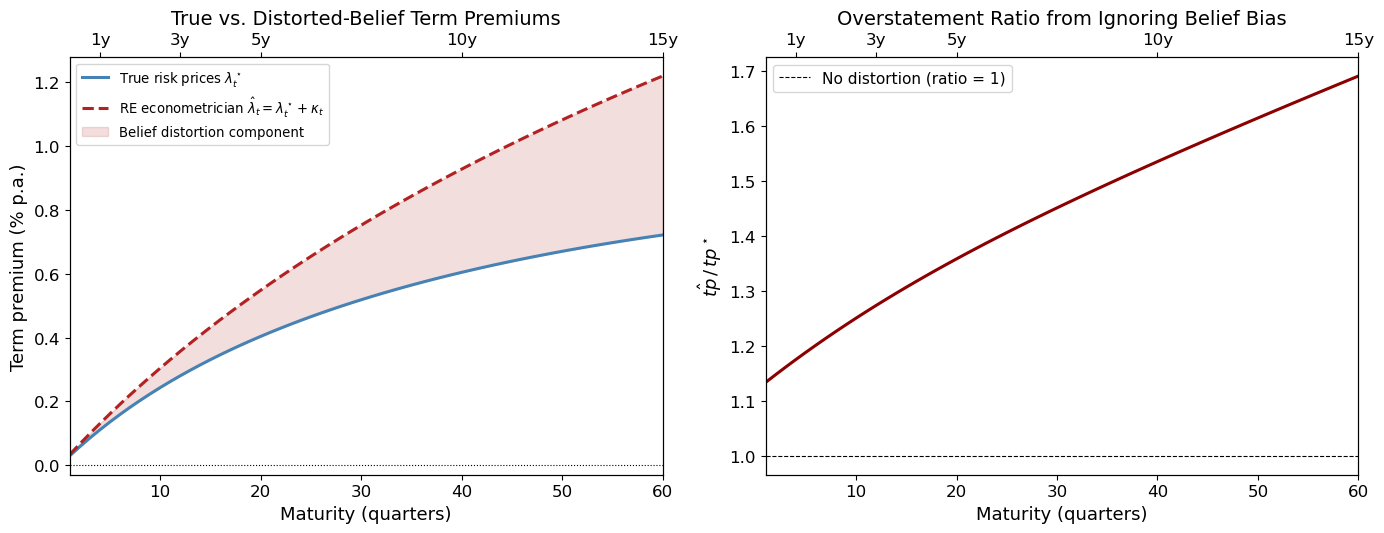

In [24]:
# ── Term premiums: true vs. distorted ──────────────────────────────────
model_true = AffineTermStructure(mu2, phi2, C2,
                                  delta0_2, delta1_2,
                                  lambda_star_0, lambda_star_z)

model_econ = AffineTermStructure(mu2, phi2, C2,
                                  delta0_2, delta1_2,
                                  lambda_hat_0, lambda_hat_z)

# Verify both models have stable Q dynamics
for name, mdl in [("True", model_true), ("Econometrician", model_econ)]:
    eigs = eigvals(mdl.phi_rn).real
    print(f"{name} model: φ^Q eigenvalues = {eigs.round(4)}, "
          f"{'✓' if all(abs(e) < 1 for e in eigs) else '✗ UNSTABLE'}")

z_ref = np.array([0.0, 0.0])
n_max_db = 60
maturities_db = np.arange(1, n_max_db + 1)

tp_true = term_premiums(model_true, z_ref, n_max_db) * 4 * 100
tp_econ = term_premiums(model_econ, z_ref, n_max_db) * 4 * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: Level comparison with shading ──
ax1.plot(maturities_db, tp_true, lw=2.2, color="steelblue",
         label=r"True risk prices $\lambda^\star_t$")
ax1.plot(maturities_db, tp_econ, lw=2.2, color="firebrick", ls="--",
         label=r"RE econometrician $\hat\lambda_t = \lambda^\star_t + \kappa_t$")
ax1.fill_between(maturities_db, tp_true, tp_econ, alpha=0.15, color="firebrick",
                 label="Belief distortion component")
ax1.axhline(0, color="black", lw=0.8, ls=":")
ax1.set_xlabel("Maturity (quarters)")
ax1.set_ylabel("Term premium (% p.a.)")
ax1.set_title("True vs. Distorted-Belief Term Premiums")
ax1.legend(fontsize=9.5)
ax1.set_xlim(1, n_max_db)

# ── Right: Ratio ──
mask = np.abs(tp_true) > 1e-8
ratio = np.full_like(tp_true, np.nan)
ratio[mask] = tp_econ[mask] / tp_true[mask]

ax2.plot(maturities_db[mask], ratio[mask], lw=2.2, color="darkred")
ax2.axhline(1, color="black", lw=0.8, ls="--", label="No distortion (ratio = 1)")
ax2.set_xlabel("Maturity (quarters)")
ax2.set_ylabel(r"$\hat{tp}\, /\, tp^\star$")
ax2.set_title("Overstatement Ratio from Ignoring Belief Bias")
ax2.legend(fontsize=11)
ax2.set_xlim(1, n_max_db)

# Year labels
for ax in (ax1, ax2):
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    year_ticks = [4, 12, 20, 40, 60]
    ax_top.set_xticks(year_ticks)
    ax_top.set_xticklabels([f"{t/4:.0f}y" for t in year_ticks])

plt.tight_layout()
plt.show()

## 12. Bond Price Recursion Verification (Appendix)

We verify the Riccati recursion by brute-force computation for small $n$.

For $n=1$: $p_t(1) = E_t[m_{t+1}] = \exp(-r_t) = \exp(-\delta_0 - \delta_1'z_t)$, so $\bar{A}_1 = -\delta_0$, $\bar{B}_1 = -\delta_1$. ✓

For $n=2$: $p_t(2) = E_t[m_{t+1}\,p_{t+1}(1)]$. We compute this using the lognormal MGF
and confirm the Riccati formulae give the same $\bar{A}_2, \bar{B}_2$.

In [25]:
# ── Appendix: verify Riccati recursion for n=1,2,3 ─────────────────────
# Use the two-factor model for this check
model = model_2f
A_bar, B_bar = model.bond_coefficients(4)
CC = model.C @ model.C.T

print("=" * 60)
print("Verification of Riccati recursion for n = 1, 2, 3")
print("=" * 60)

# n=1: Ā_1 = -δ_0,  B̄_1 = -δ_1
print(f"\nn=1:")
print(f"  Ā_1 = {A_bar[1]:.6f}  (should be -δ_0 = {-model.delta0:.6f})")
print(f"  B̄_1 = {B_bar[1]}  (should be -δ_1 = {-model.delta1})")
assert np.isclose(A_bar[1], -model.delta0)
assert np.allclose(B_bar[1], -model.delta1)
print("  ✓ Match")

# n=2: manually compute from Riccati
print(f"\nn=2: manual Riccati step")
B1 = B_bar[1]
A2_manual = A_bar[1] + B1 @ model.mu_rn + 0.5 * B1 @ CC @ B1 - model.delta0
B2_manual = model.phi_rn.T @ B1 - model.delta1
print(f"  Ā_2 (recursion) = {A_bar[2]:.8f}")
print(f"  Ā_2 (manual)    = {A2_manual:.8f}")
print(f"  B̄_2 (recursion) = {B_bar[2].round(8)}")
print(f"  B̄_2 (manual)    = {B2_manual.round(8)}")
assert np.isclose(A_bar[2], A2_manual)
assert np.allclose(B_bar[2], B2_manual)
print("  ✓ Match")

# n=3: one more step
print(f"\nn=3: manual Riccati step")
B2 = B_bar[2]
A3_manual = A_bar[2] + B2 @ model.mu_rn + 0.5 * B2 @ CC @ B2 - model.delta0
B3_manual = model.phi_rn.T @ B2 - model.delta1
print(f"  Ā_3 (recursion) = {A_bar[3]:.8f}")
print(f"  Ā_3 (manual)    = {A3_manual:.8f}")
print(f"  B̄_3 (recursion) = {B_bar[3].round(8)}")
print(f"  B̄_3 (manual)    = {B3_manual.round(8)}")
assert np.isclose(A_bar[3], A3_manual)
assert np.allclose(B_bar[3], B3_manual)
print("  ✓ Match")

print("\n" + "=" * 60)
print("All checks passed — Riccati recursion is correctly implemented.")
print("=" * 60)

Verification of Riccati recursion for n = 1, 2, 3

n=1:
  Ā_1 = -0.010000  (should be -δ_0 = -0.010000)
  B̄_1 = [-0.002 -0.001]  (should be -δ_1 = [-0.002 -0.001])
  ✓ Match

n=2: manual Riccati step
  Ā_2 (recursion) = -0.01997250
  Ā_2 (manual)    = -0.01997250
  B̄_2 (recursion) = [-0.00395  -0.001843]
  B̄_2 (manual)    = [-0.00395  -0.001843]
  ✓ Match

n=3: manual Riccati step
  Ā_3 (recursion) = -0.02991429
  Ā_3 (manual)    = -0.02991429
  B̄_3 (recursion) = [-0.00585125 -0.00254573]
  B̄_3 (manual)    = [-0.00585125 -0.00254573]
  ✓ Match

All checks passed — Riccati recursion is correctly implemented.
